# Consolida base X-Health
com transformações, flags e ajustes

In [1]:
#adicionando retorno no diretório ao caminho
import sys
sys.path.append('../')

#ignorar warnings 
import warnings
warnings.filterwarnings('ignore')

#adicionando arquivos locais
from src.globals import *
from src.eda import *
from src.plots import *
from src.auxiliar_xhealth import *
from src.models import selecionar_variaveis

2025-02-03 18:16:58.559 | INFO     | src.globals:<module>:7 - PROJ_ROOT path is C:\Users\Natalia\OneDrive\Documentos\PROJETOS\x_health


In [2]:
import pandas as pd 
import numpy as np

from loguru import logger
import csv
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

In [3]:
#mostrar todas as colunas
pd.set_option('display.max_columns',None)

### Importando base

In [4]:
#importando a base do arquivo externo
nome_base = f'{EXTERNAL_DATA_DIR}/dataset_2021-5-26-10-14.csv'
df = pd.read_csv(nome_base, sep = '\t' ,encoding = 'utf-8')

logger.info(f'Base importada com tamanho: {len(df)}')

2025-02-03 18:17:01.826 | INFO     | __main__:<module>:5 - Base importada com tamanho: 117273


In [5]:
df.head(3)

,default_3months,ioi_36months,ioi_3months,valor_por_vencer,valor_vencido,valor_quitado,quant_protestos,valor_protestos,quant_acao_judicial,acao_judicial_valor,participacao_falencia_valor,dividas_vencidas_valor,dividas_vencidas_qtd,falencia_concordata_qtd,tipo_sociedade,opcao_tributaria,atividade_principal,forma_pagamento,valor_total_pedido,month,year,default
0,0,58.000000,18.236092,0.00,0.0,242100.70,0,0.0,0,0.0,0.0,0.0,0,0,empresario (individual),simples nacional,papelaria,30/60/90,34665.674938,6,2019,0
1,1,16.052632,7.500000,224132.85,0.0,4960846.21,0,0.0,0,0.0,0.0,0.0,0,0,sociedade empresaria limitada,missing,com de equipamentos de informatica,30/60/90,7134.489373,10,2018,0
2,0,13.250000,3.904762,513043.83,0.0,158631.93,1,1800.0,0,0.0,0.0,0.0,0,0,sociedade empresaria limitada,simples nacional,servicos de vigilancia e guarda,missing,72653.621143,4,2018,0


In [6]:
#cria um df de backup
backup = df.copy()

In [7]:
# Substituindo "missing" por NaN
df.replace("missing", pd.NA, inplace=True)

In [8]:
#
df = criar_flags(df)

## Cria separação por trimestre
a sazonalidade por trimestre indica um comportamento maior de inadimplência por período

In [9]:
#Cria separação por trimestres
df["periodo_fiscal"] = df["month"].apply(lambda x: "1T" if x in [1, 2, 3] else 
                                         "2T" if x in [4, 5, 6] else 
                                         "3T" if x in [7, 8, 9] else "4T")

In [10]:
df['periodo_fiscal'].unique()

array(['2T', '4T', '3T', '1T'], dtype=object)

## Remove variáveis
- "year" → Não demonstrou relação com a inadimplência.
- "month" → Substituído por "periodo_fiscal".
- "default_3months" → Pode causar data leakage por ser informação futura.

In [11]:
colunas_excluir = ["year", "month", "default_3months"]

# Verifica se as colunas existem no DataFrame antes de tentar removê-las
colunas_remover = [col for col in colunas_excluir if col in df.columns]

df = df.drop(columns=colunas_remover, errors="ignore")

## Agrupamento de categóricas

In [12]:
df['forma_pagamento_agrup'] = agrupar_prazo(df, 'forma_pagamento')
df['tipo_sociedade_agrup'] = agrupar_tipo_sociedade(df, 'tipo_sociedade')
df['atividade_principal_agrup'] = agrupar_atividade_principal(df, 'atividade_principal')
df['opcao_tributaria_agrup'] = agrupar_opcao_tributaria(df, "opcao_tributaria")

In [13]:
df = criar_variaveis_combinadas(df)

## checkpoint

In [14]:
nome_base = f'{INTERIM_DATA_DIR}/x-health-consolid.csv'
df.to_csv(nome_base, sep = '\t' ,encoding = 'utf-8', index=False)

In [15]:
checkpoint = pd.read_csv(nome_base, sep = '\t' ,encoding = 'utf-8')

In [16]:
checkpoint.columns.values

array(['ioi_36months', 'ioi_3months', 'valor_por_vencer', 'valor_vencido',
       'valor_quitado', 'quant_protestos', 'valor_protestos',
       'quant_acao_judicial', 'acao_judicial_valor',
       'participacao_falencia_valor', 'dividas_vencidas_valor',
       'dividas_vencidas_qtd', 'falencia_concordata_qtd',
       'tipo_sociedade', 'opcao_tributaria', 'atividade_principal',
       'forma_pagamento', 'valor_total_pedido', 'default',
       'flag_acao_judicial', 'flag_protesto', 'flag_dividas_vencidas',
       'flag_valor_vencido', 'flag_valor_por_vencer',
       'flag_valor_quitado', 'periodo_fiscal', 'forma_pagamento_agrup',
       'tipo_sociedade_agrup', 'atividade_principal_agrup',
       'opcao_tributaria_agrup', 'razao_valor_vencido',
       'razao_valor_quitado', 'media_ioi', 'soma_riscos',
       'historico_pagamento'], dtype=object)

In [17]:
# faz transformação logaritmica para minimizar outlier
df["valor_quitado_log"] = np.log1p(df["valor_quitado"])
df["valor_por_vencer_log"] = np.log1p(df["valor_por_vencer"])
df["valor_total_pedido_log"] = np.log1p(df["valor_total_pedido"])
df["valor_vencido_log"] = np.log1p(df["valor_vencido"])
df["valor_protestos_log"] = np.log1p(df["valor_protestos"])
df["acao_judicial_valor_log"] = np.log1p(df["acao_judicial_valor"])
df["dividas_vencidas_valor_log"] = np.log1p(df["dividas_vencidas_valor"])

In [18]:
# Variáveis sem muitos outliers, mantendo a distribuição
scaler = MinMaxScaler()
df[["ioi_3months_normal", "ioi_36months_normal"]] = scaler.fit_transform(df[["ioi_3months", "ioi_36months",]])

In [19]:
scaler = StandardScaler()
df[["quant_protestos_normal", "quant_acao_judicial_normal", "falencia_concordata_qtd_normal"]] = scaler.fit_transform(df[["quant_protestos", "quant_acao_judicial", "falencia_concordata_qtd"]])

## LabelEncoder

In [20]:
categorical_cols = identificar_variaveis_categoricas(df)

# Aplicando Label Encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # Converte para string antes do encoding
    label_encoders[col] = le  # Armazena os encoders se precisar inverter depois


# Seleção automática de Variáveis


### Information Value (IV)  >= 0.02) ###
                          Variavel        IV
0           opcao_tributaria_agrup  0.191230
1                 opcao_tributaria  0.191230
2              historico_pagamento  0.178030
3                   periodo_fiscal  0.145501
4               flag_valor_vencido  0.142302
5            forma_pagamento_agrup  0.141967
6              razao_valor_vencido  0.131054
7                valor_vencido_log  0.098016
8                    valor_vencido  0.098016
9                      ioi_3months  0.095854
10              ioi_3months_normal  0.095854
11             razao_valor_quitado  0.092974
12             atividade_principal  0.076543
13                 forma_pagamento  0.070292
14             ioi_36months_normal  0.069786
15                    ioi_36months  0.069786
16                       media_ioi  0.064930
17              valor_total_pedido  0.063829
18          valor_total_pedido_log  0.063751
19            tipo_sociedade_agrup  0.050422
20           

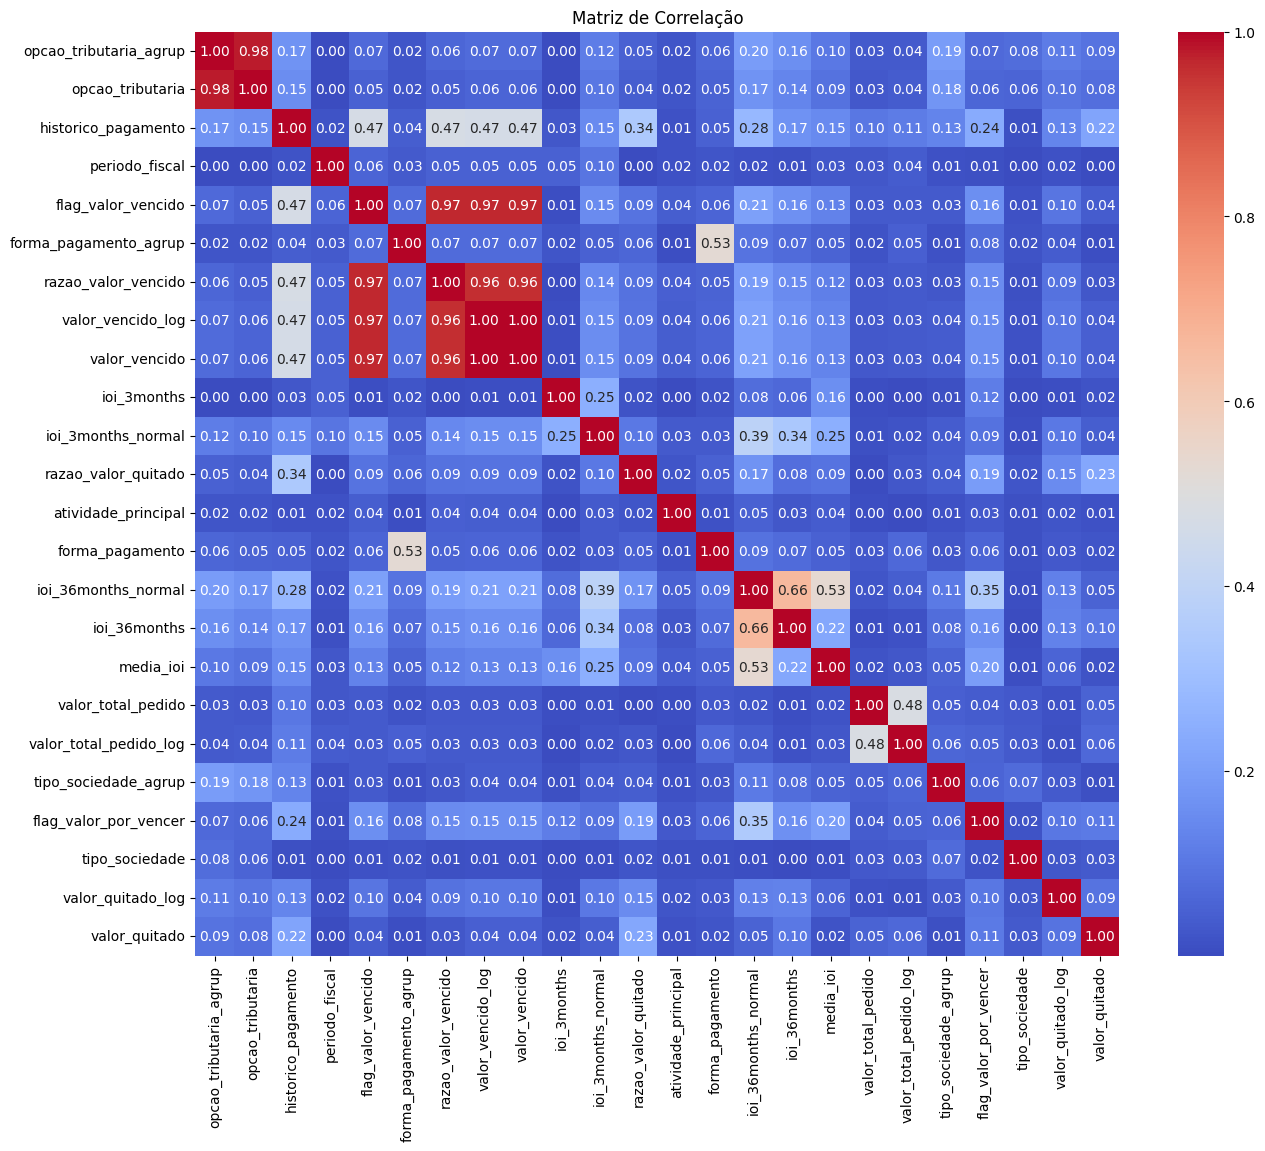


### Mutual Information (MI) ###
                  Variavel        MI
0   opcao_tributaria_agrup  0.024902
16   flag_valor_por_vencer  0.020697
4    forma_pagamento_agrup  0.017782
2           periodo_fiscal  0.013832
3       flag_valor_vencido  0.013537
15    tipo_sociedade_agrup  0.013269
17          tipo_sociedade  0.012656
1      historico_pagamento  0.011888
9          forma_pagamento  0.009756
6       ioi_3months_normal  0.009131
11            ioi_36months  0.008045
7      razao_valor_quitado  0.007876
12               media_ioi  0.007513
13      valor_total_pedido  0.007476
5              ioi_3months  0.007461
14  valor_total_pedido_log  0.007262
8      atividade_principal  0.006698
10     ioi_36months_normal  0.006617
19           valor_quitado  0.004942
18       valor_quitado_log  0.004421


In [21]:
variaveis_selecionadas = selecionar_variaveis(df, 'default', figsize=(15,12), mi_top_n = 15)

In [22]:
variaveis_selecionadas.columns


Index(['opcao_tributaria_agrup', 'flag_valor_por_vencer',
       'forma_pagamento_agrup', 'periodo_fiscal', 'flag_valor_vencido',
       'tipo_sociedade_agrup', 'tipo_sociedade', 'historico_pagamento',
       'forma_pagamento', 'ioi_3months_normal', 'ioi_36months',
       'razao_valor_quitado', 'media_ioi', 'valor_total_pedido', 'ioi_3months',
       'default'],
      dtype='object')

## Salvando bases processadas

### DF completo

In [23]:
nome_base = f'{PROCESSED_DATA_DIR}/01-x-health-consolid.csv'
df.to_csv(nome_base, sep = '\t' ,encoding = 'utf-8', index=False)

In [24]:
checkpoint = pd.read_csv(nome_base, sep = '\t' ,encoding = 'utf-8')

### DF com seleção automática

In [ ]:
nome_base = f'{PROCESSED_DATA_DIR}/01-x-health-consolid_auto.csv'
df.to_csv(nome_base, sep = '\t' ,encoding = 'utf-8', index=False)

In [ ]:
checkpoint = pd.read_csv(nome_base, sep = '\t' ,encoding = 'utf-8')

### DF com seleção manual

In [ ]:
colunas ={
    'opcao_tributaria_agrup' ,
    'flag_valor_por_vencer' ,
    'forma_pagamento_agrup',
    'periodo_fiscal',
    'flag_valor_vencido',
    'tipo_sociedade_agrup' ,
    'tipo_sociedade',
    'historico_pagamento',
    'forma_pagamento',
    'ioi_3months_normal',
    'ioi_36months' ,
    'razao_valor_quitado',
    'media_ioi',
    'valor_total_pedido',
    'ioi_3months',
    'valor_total_pedido_log',
    'atividade_principal',
    'ioi_36months_normal',
    'valor_quitado',
    'valor_quitado_log'
}

In [ ]:
nome_base = f'{PROCESSED_DATA_DIR}/01-x-health-consolid_auto.csv'
df[colunas].to_csv(nome_base, sep = '\t' ,encoding = 'utf-8', index=False)

In [ ]:
checkpoint = pd.read_csv(nome_base, sep = '\t' ,encoding = 'utf-8')